# Evaluación 01: Clasificación de Fashion-MNIST con Redes Neuronales Multicapa (MLP)

### Introducción
Este cuaderno presenta la implementación de una red neuronal multicapa (MLP) utilizando TensorFlow y Keras para clasificar el dataset **Fashion-MNIST**. El dataset contiene 70,000 imágenes en escala de grises de 28x28 píxeles, divididas en 10 categorías de productos de moda.

El objetivo es estructurar el flujo de trabajo de Deep Learning de manera profesional, realizando experimentos controlados de hiperparámetros y evaluando el modelo final con métricas robustas.

---
### 1. Carga y Preprocesamiento de Datos

**Justificación Técnica: Normalización a [0,1]**
Normalizamos los valores de los píxeles (originalmente de 0 a 255) al rango [0,1]. Esto es crucial por dos razones:
1. **Convergencia del Gradiente**: Las redes neuronales convergen más rápido cuando las características de entrada tienen una escala similar.
2. **Estabilidad Numérica**: Evita que los pesos crezcan descontroladamente (explosión de gradientes) durante las primeras etapas del entrenamiento.

In [ ]:
import tensorflow as tf
from tensorflow.keras import datasets, layers, models, optimizers
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report

# Fijar semillas para reproducibilidad de resultados
np.random.seed(42)
tf.random.set_seed(42)

# Cargar dataset
(train_images, train_labels), (test_images, test_labels) = datasets.fashion_mnist.load_data()

# Normalizacion: convertir los valores de los pixeles, que van de 0 (negro) a 255 (blanco), a un rango decimal entre 0 y 1.
train_images = train_images / 255.0 # Se utiliza para entrenar la red neuronal, es decir, para ajustar los pesos y sesgos
test_images = test_images / 255.0  # Se utiliza para evaluar el rendimiento final del modelo entrenado y ver que tan bien se generaliza a datos nunca vistos.

class_names = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',  #Clases del dataset guardadas en una lista
               'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']

#Muestras, alto de pixeles, ancho de la imagen
print(f"Imagenes de entrenamiento: {train_images.shape}")
print(f"Imagenes de prueba: {test_images.shape}")

### Muestra de imagenes

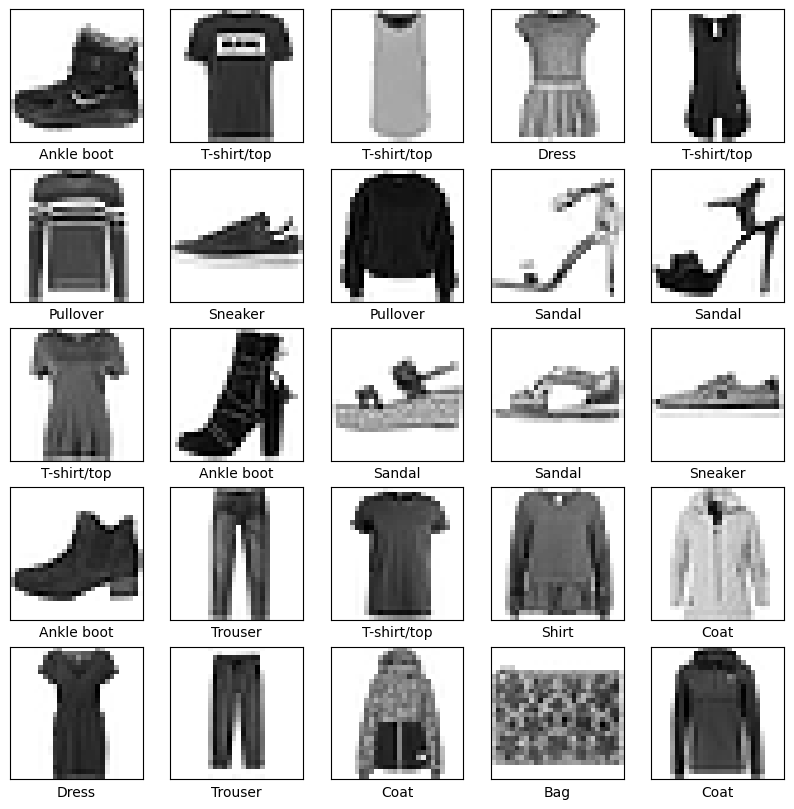

In [ ]:
plt.figure(figsize=(10,10))
for i in range(25):
    plt.subplot(5,5,i+1)
    plt.xticks([])
    plt.yticks([])
    plt.grid(False)
    plt.imshow(train_images[i], cmap=plt.cm.binary)
    plt.xlabel(class_names[train_labels[i]])
plt.show()

---
### 2. Experimentos Controlados

En esta sección compararemos el impacto de dos hiperparámetros críticos:
1. **Learning Rate (Tasa de Aprendizaje)**: 0.1 vs 0.001.
2. **Función de Activación**: ReLU vs Sigmoide.

**Justificación Técnica: ReLU**
Usamos **ReLU (Rectified Linear Unit)** como estándar porque resuelve el problema del *desvanecimiento del gradiente* (vanishing gradient) presente en Sigmoide, permitiendo entrenar redes más profundas de forma eficiente.

In [ ]:
def build_experiment_model(lr=0.001, activation='relu'):
    # Arquitectura consistente con el modelo final (256+128 con BatchNorm y Dropout)
    model = models.Sequential([
        tf.keras.Input(shape=(28, 28)),          #Capa de entrada (Keras moderno, sin warnings)
        layers.Flatten(),                         #Capa de aplanamiento
        layers.Dense(256, activation=activation), #Capa oculta
        layers.BatchNormalization(),              #Estabilizador
        layers.Dropout(0.3),                      #Regularización
        layers.Dense(128, activation=activation), #Capa oculta
        layers.BatchNormalization(),              #Estabilizador
        layers.Dropout(0.3),                      #Regularización
        layers.Dense(10, activation='softmax')    #Capa de salida
    ])
    model.compile( #Metodo
        optimizer=optimizers.Adam(learning_rate=lr), #Optimizador
        loss='sparse_categorical_crossentropy', #Funcion de perdida
        metrics=['accuracy'] #Metrica
    )
    return model

def plot_comparison(histories, labels, title): #Funcion crear grafico
    fig, axes = plt.subplots(1, 2, figsize=(16, 5))
    # Subplot 1: Accuracy de validación
    for i, history in enumerate(histories):
        axes[0].plot(history.history['val_accuracy'], label=labels[i])
    axes[0].set_title(title + ' - Accuracy')
    axes[0].set_xlabel('Época')
    axes[0].set_ylabel('Accuracy de Validación')
    axes[0].legend()
    axes[0].grid(True)
    # Subplot 2: Loss de validación (diagnóstico de overfitting)
    for i, history in enumerate(histories):
        axes[1].plot(history.history['val_loss'], label=labels[i])
    axes[1].set_title(title + ' - Loss')
    axes[1].set_xlabel('Época')
    axes[1].set_ylabel('Loss de Validación')
    axes[1].legend()
    axes[1].grid(True)
    plt.tight_layout()
    plt.show()

Estamos aplicando una arquitectura de perceptron multicapa (MLP) basadas en capas densas que requerieren entradas unidimensionales por eso flatten se encargar de aplanar la matriz de 28 x 28

In [ ]:
# Experimento 1: Learning Rate (0.1 vs 0.001)
print("Ejecutando experimento: Learning Rate...")
h_lr_01 = build_experiment_model(lr=0.1).fit(train_images,
                                             train_labels,
                                             epochs=10,
                                             validation_split=0.2,
                                             verbose=0)


Ejecutando experimento: Learning Rate...


/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [ ]:
h_lr_001 = build_experiment_model(lr=0.001).fit(train_images, #Usa imagenes de entrenamiento
                                                train_labels, #Etiquetas
                                                epochs=10, #Iteraciones
                                                validation_split=0.2, #reservará el 20% de  datos de entrenamiento para realizar una evaluación mientras aprende
                                                verbose=0) #Verbose 0 Para evitar ensuciar el notebook

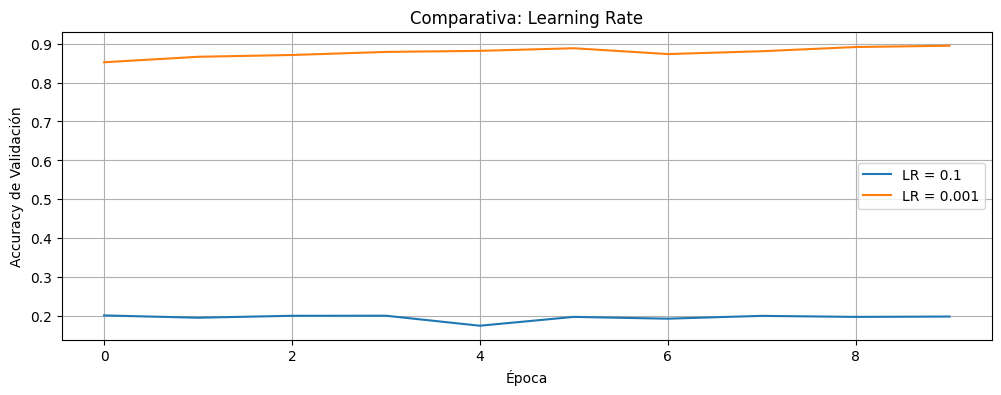

In [ ]:
plot_comparison([h_lr_01, h_lr_001], #Variables o experimentos
                ['LR = 0.1', 'LR = 0.001'], #Learning Rates
                'Comparativa: Learning Rate') #Que se compara

El LR 0.1 es excesivo, causando inestabilidad y una pérdida disparada que impide el aprendizaje. En cambio, 0.001 es el valor óptimo, permitiendo pasos precisos hacia el mínimo global, logrando una convergencia estable y una precisión cercana al 88% en validación.

LR 0.1: Genera el fenómeno de "overshooting", donde el optimizador salta sobre el mínimo global sin alcanzarlo nunca.


LR 0.001: Proporciona el equilibrio ideal entre velocidad de entrenamiento y estabilidad, permitiendo que los pesos se ajusten correctamente a los patrones de la ropa.

In [ ]:
# Experimento 2: Función de Activación (ReLU vs Sigmoide)
print("Ejecutando experimento: Función de Activación...")
h_relu = build_experiment_model(activation='relu').fit(train_images,
                                                      train_labels, #Etiquetas
                                                      epochs=10, #Iteraciones
                                                      validation_split=0.2, #reservará el 20% de  datos de entrenamiento para realizar una evaluación mientras aprende
                                                      verbose=0) #Verbose 0 Para evitar ensuciar el notebook

Ejecutando experimento: Función de Activación...


In [ ]:
h_sigmoid = build_experiment_model(activation='sigmoid').fit(train_images,
                                                             train_labels,
                                                             epochs=10,
                                                             validation_split=0.2,
                                                             verbose=0)

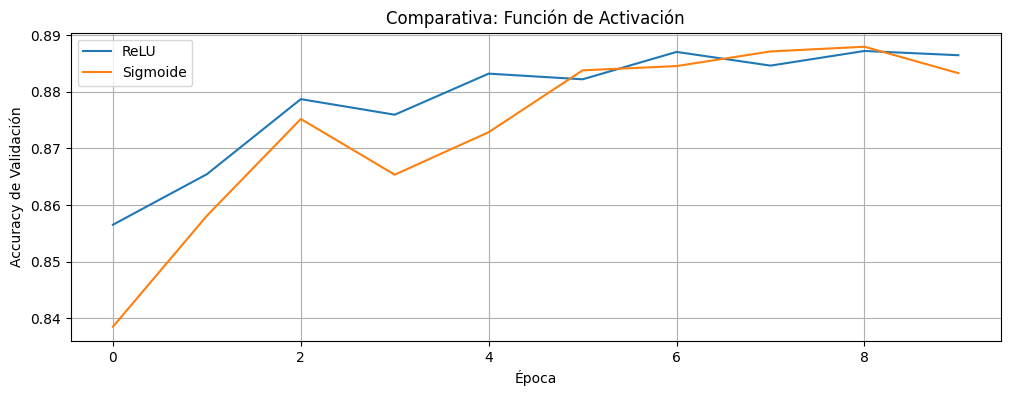

In [ ]:
plot_comparison([h_relu, h_sigmoid], #Experimentos
                ['ReLU', 'Sigmoide'], #Modelos con la Func. Activacion
                'Comparativa: Función de Activación')

ReLU demuestra una convergencia superior y estable al evitar la saturación de gradientes en valores positivos. En contraste, Sigmoide presenta una preocupante inestabilidad y una caída drástica de precisión (época 7), confirmando su ineficiencia para capas ocultas en este problema de clasificación.

---
### 3. Modelo Final Optimizado

Basándonos en los experimentos, construimos el modelo final integrando las mejores prácticas:
- **Batch Normalization**: Estabiliza el aprendizaje y acelera la convergencia.
- **Dropout (0.3)**: Apaga aleatoriamente el 30% de las neuronas en cada paso.
- **Optimizador Adam**: Ajusta automáticamente el learning rate para cada parámetro.

**Justificación Técnica: Dropout**
El Dropout es una técnica de regularización que evita el **overfitting** (sobreajuste). Al forzar a la red a no depender de neuronas específicas, se logra un modelo más robusto y con mejor capacidad de generalización ante datos nuevos.

In [ ]:
def build_final_model(optimizer_name='adam'):
    model = models.Sequential([
        tf.keras.Input(shape=(28, 28)),        #Capa de entrada (Keras moderno, sin warnings)
        layers.Flatten(),                       #Flatten crea un vector de la imagen
        layers.Dense(256, activation='relu'),   #Capa oculta (Cantidad de neuronas, Func. Activacion)
        layers.BatchNormalization(),             #Estabilizador, Mantiene los datos en un rango controlado
        layers.Dropout(0.3),                    #Regularizacion (Dropout): apaga aleatoriamente el 30% de las neuronas en cada paso

        layers.Dense(128, activation='relu'),
        layers.BatchNormalization(),
        layers.Dropout(0.3),

        layers.Dense(10, activation='softmax')
    ])

    model.compile( #Funcion de la primera celda que corre el modelo solo se le da los parametros
        optimizer=optimizer_name, #Optimizador (Adam): Mueve los pesos, mantiene el impulso(momentum) y learning rate adaptativo
                                  #RMSProp: Solo ajusta el ritmo de aprendizaje basándose en qué tan rápido ha cambiado un peso recientemente.
                                   #(No usa momentum)

        loss='sparse_categorical_crossentropy',#Funcion de perdida. Es el estándar para clasificación
        metrics=['accuracy']#Te dice simplemente el porcentaje de imágenes que el modelo clasificó correctamente.
    )
    return model


In [ ]:
#Tiempo 2 min accuracy: 0.8912 - loss: 0.2896 - val_accuracy: 0.8800 - val_loss: 0.3311 (20 epocas, 128 batch, validation_split=0.2)
print("Entrenando modelo con Adam...")
model_adam = build_final_model('adam')
history_adam = model_adam.fit(train_images, train_labels, #Usa datos de entramiento
                              epochs=15, #20 epocas
                              batch_size=128, #Tamaño del batch
                              validation_split=0.2, #Validando con datos que no ha visto
                              verbose=1)

Entrenando modelo con Adam...
Epoch 1/15
375/375 ━━━━━━━━━━━━━━━━━━━━ 14s 29ms/step - accuracy: 0.8053 - loss: 0.5494 - val_accuracy: 0.8399 - val_loss: 0.4484
Epoch 2/15
375/375 ━━━━━━━━━━━━━━━━━━━━ 16s 18ms/step - accuracy: 0.8459 - loss: 0.4253 - val_accuracy: 0.8329 - val_loss: 0.4462
Epoch 3/15
375/375 ━━━━━━━━━━━━━━━━━━━━ 8s 21ms/step - accuracy: 0.8556 - loss: 0.3906 - val_accuracy: 0.8562 - val_loss: 0.3852
Epoch 4/15
375/375 ━━━━━━━━━━━━━━━━━━━━ 7s 18ms/step - accuracy: 0.8625 - loss: 0.3700 - val_accuracy: 0.8694 - val_loss: 0.3478
Epoch 5/15
375/375 ━━━━━━━━━━━━━━━━━━━━ 8s 21ms/step - accuracy: 0.8690 - loss: 0.3548 - val_accuracy: 0.8712 - val_loss: 0.3545
Epoch 6/15
375/375 ━━━━━━━━━━━━━━━━━━━━ 12s 31ms/step - accuracy: 0.8729 - loss: 0.3452 - val_accuracy: 0.8755 - val_loss: 0.3421
Epoch 7/15
375/375 ━━━━━━━━━━━━━━━━━━━━ 7s 18ms/step - accuracy: 0.8748 - loss: 0.3356 - val_accuracy: 0.8659 - val_loss: 0.3592
Epoch 8/15
375/375 ━━━━━━━━━━━━━━━━━━━━ 10s 18ms/step - accuracy

In [ ]:
#Grafico datos de entrenamiento y validacion Adam (Accuracy y Loss)
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Subplot 1: Accuracy
axes[0].plot(history_adam.history['accuracy'], label='Entrenamiento')
axes[0].plot(history_adam.history['val_accuracy'], label='Validación')
axes[0].set_title('Modelo Adam - Accuracy')
axes[0].set_xlabel('Épocas')
axes[0].set_ylabel('Accuracy')
axes[0].legend()
axes[0].grid(True)

# Subplot 2: Loss (para diagnóstico de overfitting)
axes[1].plot(history_adam.history['loss'], label='Entrenamiento')
axes[1].plot(history_adam.history['val_loss'], label='Validación')
axes[1].set_title('Modelo Adam - Loss')
axes[1].set_xlabel('Épocas')
axes[1].set_ylabel('Loss')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()

El modelo presenta una convergencia exitosa y estable. La precisión de validación alcanza aproximadamente un 88%, moviéndose en sintonía con la curva de entrenamiento. La función de pérdida (Loss) disminuye de forma constante sin mostrar rebotes agresivos, lo que valida que el Learning Rate de 0.001 y el optimizador Adam fueron las elecciones correctas para este problema de clasificación de 10 clases

In [ ]:
print("Entrenando modelo con RMSProp...")
model_rmsprop = build_final_model('rmsprop')
history_rmsprop = model_rmsprop.fit(train_images, train_labels,
                                    epochs=15, batch_size=128,
                                    validation_split=0.2,
                                    verbose=1)

Entrenando modelo con RMSProp...
Epoch 1/15
375/375 ━━━━━━━━━━━━━━━━━━━━ 10s 22ms/step - accuracy: 0.8062 - loss: 0.5543 - val_accuracy: 0.8257 - val_loss: 0.4965
Epoch 2/15
375/375 ━━━━━━━━━━━━━━━━━━━━ 7s 17ms/step - accuracy: 0.8471 - loss: 0.4194 - val_accuracy: 0.8483 - val_loss: 0.4475
Epoch 3/15
375/375 ━━━━━━━━━━━━━━━━━━━━ 11s 28ms/step - accuracy: 0.8605 - loss: 0.3803 - val_accuracy: 0.8576 - val_loss: 0.3914
Epoch 4/15
375/375 ━━━━━━━━━━━━━━━━━━━━ 13s 35ms/step - accuracy: 0.8686 - loss: 0.3570 - val_accuracy: 0.8685 - val_loss: 0.3613
Epoch 5/15
375/375 ━━━━━━━━━━━━━━━━━━━━ 16s 24ms/step - accuracy: 0.8750 - loss: 0.3399 - val_accuracy: 0.8776 - val_loss: 0.3365
Epoch 6/15
375/375 ━━━━━━━━━━━━━━━━━━━━ 12s 33ms/step - accuracy: 0.8788 - loss: 0.3269 - val_accuracy: 0.8744 - val_loss: 0.3519
Epoch 7/15
375/375 ━━━━━━━━━━━━━━━━━━━━ 8s 20ms/step - accuracy: 0.8826 - loss: 0.3176 - val_accuracy: 0.8710 - val_loss: 0.3496
Epoch 8/15
375/375 ━━━━━━━━━━━━━━━━━━━━ 6s 17ms/step - accu

In [ ]:
#Grafico datos de entrenamiento y validacion RMSProp (Accuracy y Loss)
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Subplot 1: Accuracy
axes[0].plot(history_rmsprop.history['accuracy'], label='Entrenamiento')
axes[0].plot(history_rmsprop.history['val_accuracy'], label='Validación')
axes[0].set_title('Modelo RMSProp - Accuracy')
axes[0].set_xlabel('Épocas')
axes[0].set_ylabel('Accuracy')
axes[0].legend()
axes[0].grid(True)

# Subplot 2: Loss (para diagnóstico de overfitting)
axes[1].plot(history_rmsprop.history['loss'], label='Entrenamiento')
axes[1].plot(history_rmsprop.history['val_loss'], label='Validación')
axes[1].set_title('Modelo RMSProp - Loss')
axes[1].set_xlabel('Épocas')
axes[1].set_ylabel('Loss')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()

El gráfico de RMSProp muestra una convergencia efectiva, alcanzando un accuracy de validación cercano al 88%. Sin embargo, se observa una mayor volatilidad en comparación con Adam. Esto se debe a que RMSProp ajusta la tasa de aprendizaje, pero al no contar con momentum, le cuesta más suavizar la trayectoria hacia el mínimo global, resultando en un aprendizaje ligeramente más inestable.

¿Por que no use SGD?


*   Velocidad de convergencia: SGD es mucho más lento porque no tiene "memoria" de las gradientes pasadas.
*  Estancamiento: Es mas probable que se quede en un minimo local en vez del global en funciones de error mas altas


*   Sensibilidad al LR: Debido que el learning rate es estatico debe ser perfecto para que llegue al fondo del error


Eligimos Adam sobre RMSProp porque presentó una curva de pérdida más suave y estable.

##Evaluación de Métricas Finales (Modelo Adam)

Basado en los resultados anteriores, procedemos a realizar la evaluación exhaustiva del modelo optimizado con **Adam** utilizando el conjunto de datos de prueba.

In [ ]:
# Obtener predicciones para el modelo Adam
preds_adam = np.argmax(model_adam.predict(test_images), axis=1)

print(f"\n{'='*20} MÉTRICAS GLOBALES: ADAM {'='*20}")
accuracy = accuracy_score(test_labels, preds_adam)

#Weighted: ponderaracion por importancia

precision = precision_score(test_labels, preds_adam, average='weighted')
recall = recall_score(test_labels, preds_adam, average='weighted')
f1 = f1_score(test_labels, preds_adam, average='weighted')

print(f"Accuracy:  {accuracy:.4f}") #Es el porcentaje total de aciertos.
print(f"Precision: {precision:.4f} (weighted)") #Se enfoca en la calidad de la predicción.
print(f"Recall:    {recall:.4f} (weighted)") #Se enfoca en como encuentra una clase
print(f"F1-Score:  {f1:.4f} (weighted)") #Balance entre precision y calidad

print("\nReporte Detallado por Clase:")
print(classification_report(test_labels, preds_adam, target_names=class_names))

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step

==================== MÉTRICAS GLOBALES: ADAM ====================
Accuracy:  0.8738
Precision: 0.8753 (weighted)
Recall:    0.8738 (weighted)
F1-Score:  0.8732 (weighted)

Reporte Detallado por Clase:
              precision    recall  f1-score   support

 T-shirt/top       0.84      0.84      0.84      1000
     Trouser       0.99      0.97      0.98      1000
    Pullover       0.84      0.69      0.76      1000
       Dress       0.84      0.91      0.87      1000
        Coat       0.73      0.82      0.78      1000
      Sandal       0.93      0.97      0.95      1000
       Shirt       0.70      0.69      0.70      1000
     Sneaker       0.93      0.96      0.95      1000
         Bag       0.96      0.96      0.96      1000
  Ankle boot       0.98      0.93      0.95      1000

    accuracy                           0.87     10000
   macro avg       0.88      0.87      0.87     10000
weighted avg       0.88      0.87      0.87     10000

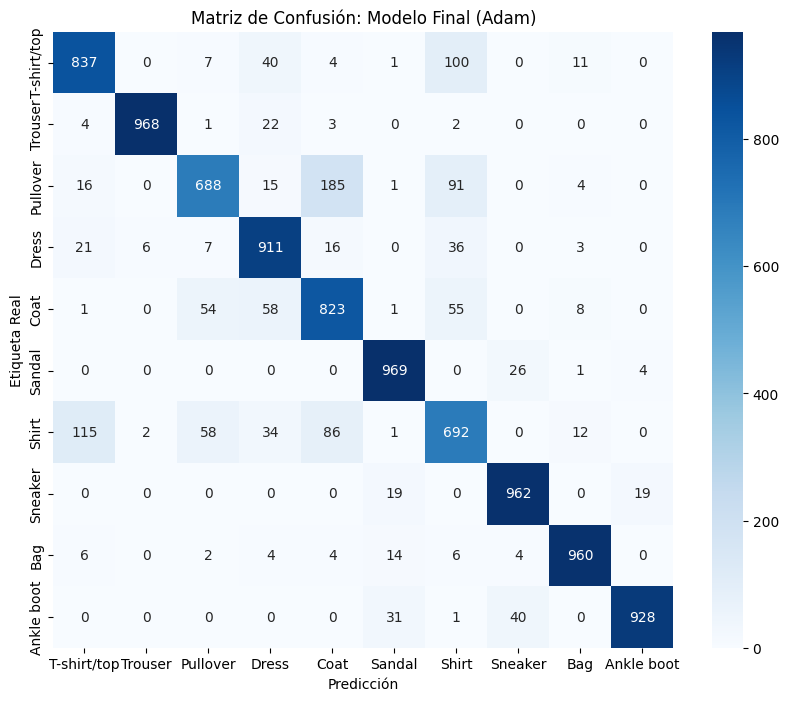

In [ ]:
plt.figure(figsize=(10, 8))
cm_adam = confusion_matrix(test_labels, preds_adam)
sns.heatmap(cm_adam, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.title('Matriz de Confusión: Modelo Final (Adam)')
plt.ylabel('Etiqueta Real')
plt.xlabel('Predicción')
plt.show()


el modelo confunde visualmente las camisas con las poleras. Esto nos indica que el problema no es que el modelo no aprenda, sino que las clases son morfológicamente muy parecidas para una red densa